In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sakshisatre/tips-dataset/tip.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/sakshisatre/tips-dataset/tip.csv")

In [4]:
df.shape

(244, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [6]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# **univariate analysis**

***countplot for categorical columns and discrete numerical columns***

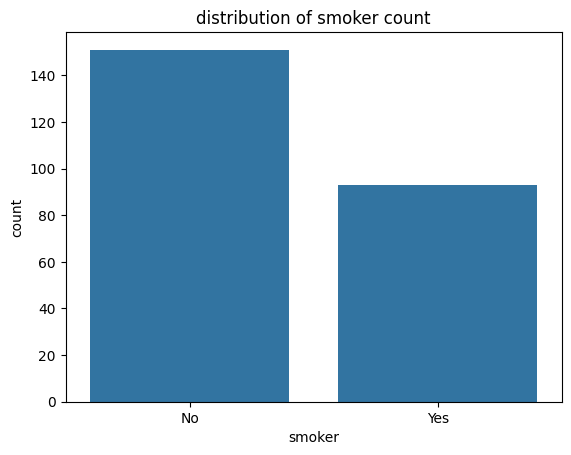

In [8]:
sns.countplot(x = df['smoker'], data=df)
plt.title("distribution of smoker count")
plt.show()

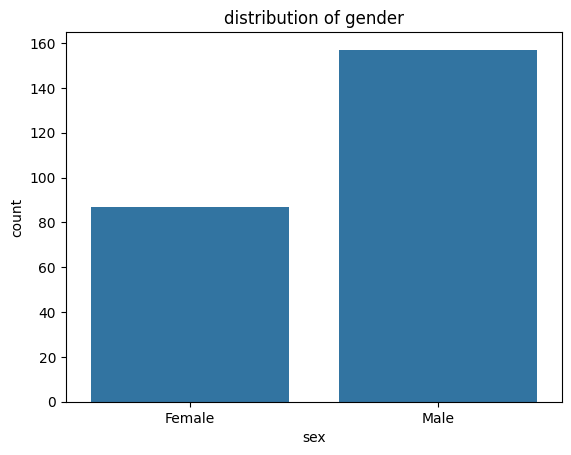

In [9]:
sns.countplot(x = df['sex'], data = df)
plt.title("distribution of gender")
plt.show()

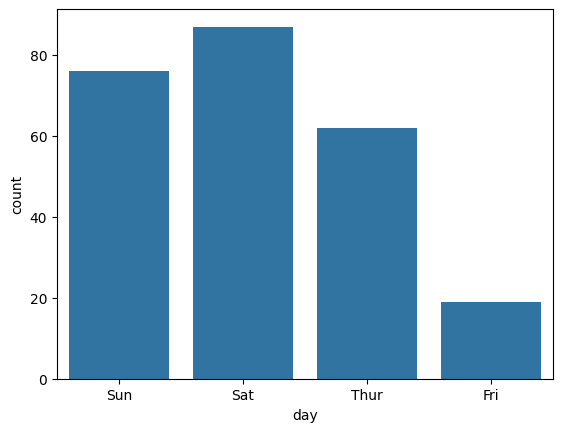

In [10]:
sns.countplot(x = df['day'], data=df)
plt.show()

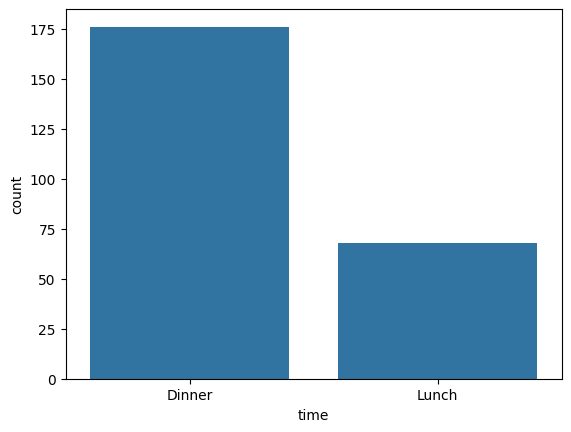

In [11]:
sns.countplot(x = df['time'], data = df)
plt.show()

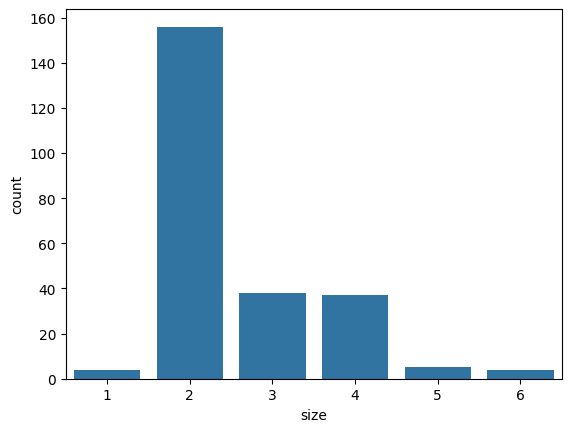

In [12]:
sns.countplot(x = df['size'], data=df)
plt.show()

***boxplot and histplot for continuous numerical column***

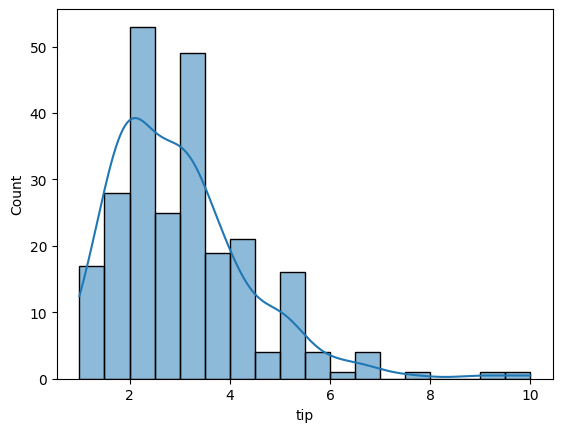

In [13]:
sns.histplot(df['tip'],kde = True)
plt.show()

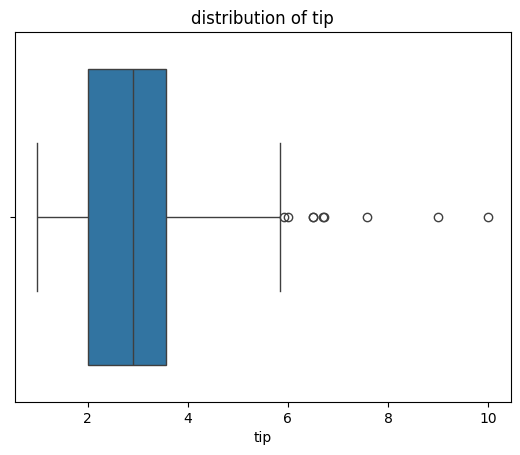

In [14]:
sns.boxplot(x = df['tip'])
plt.title("distribution of tip")
plt.show()

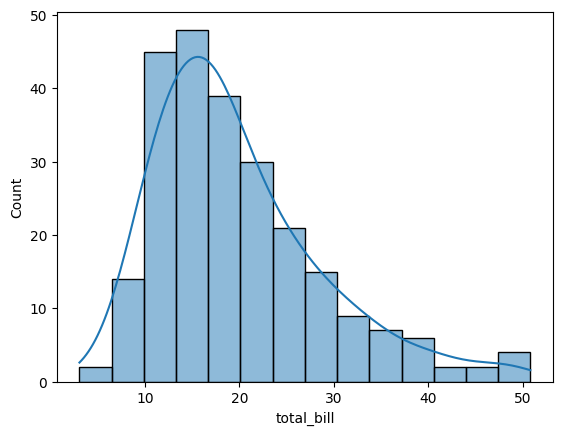

In [15]:
sns.histplot(df['total_bill'],kde = True)
plt.show()

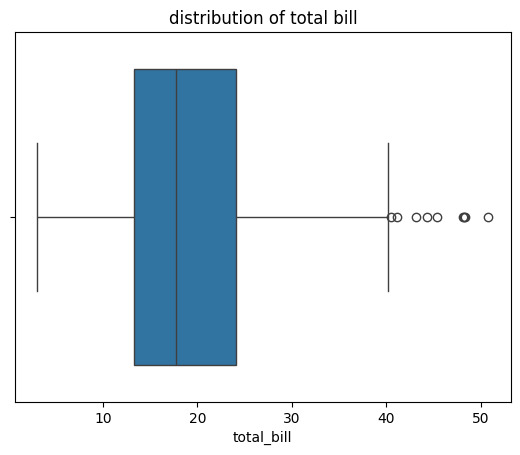

In [16]:
sns.boxplot(x = df['total_bill'])
plt.title("distribution of total bill")
plt.show()

# **BIVARIATE ANALYSIS**

**count plot for gender vs smoke**

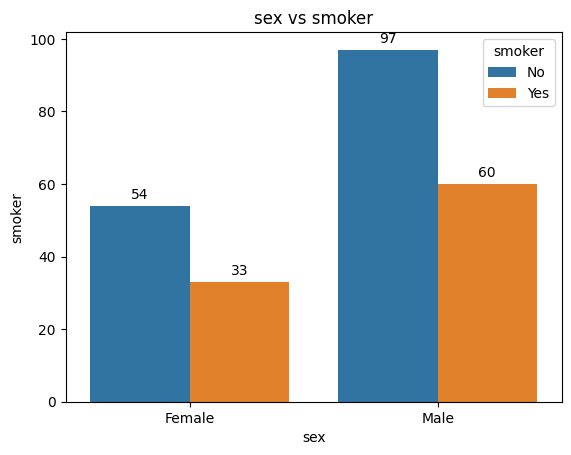

In [17]:
ax = sns.countplot(x = df['sex'], hue ='smoker', data= df)

for con in ax.containers:
    ax.bar_label(con, padding=3)

plt.title("sex vs smoker")
plt.xlabel("sex")
plt.ylabel("smoker")
plt.show()

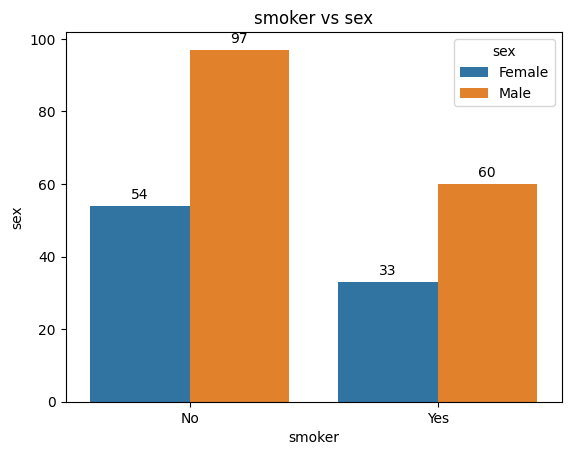

In [18]:
ax = sns.countplot(x = df['smoker'], hue ='sex', data= df)

for con in ax.containers:
    ax.bar_label(con, padding=3)

plt.title("smoker vs sex")
plt.xlabel("smoker")
plt.ylabel("sex")
plt.show()

In [19]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

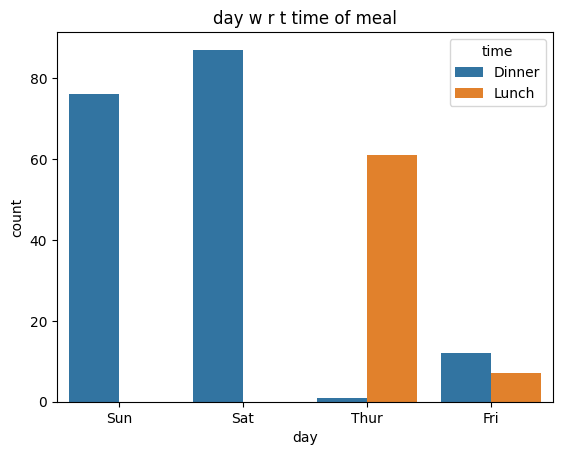

In [20]:
sns.countplot(x = df['day'], hue = 'time', data=df)
plt.title("day w r t time of meal")
plt.show()

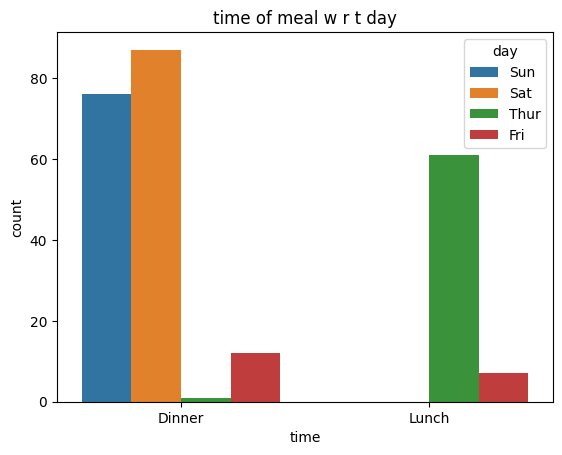

In [21]:
sns.countplot(x = df['time'], hue = 'day', data=df)
plt.title("time of meal w r t day")
plt.show()

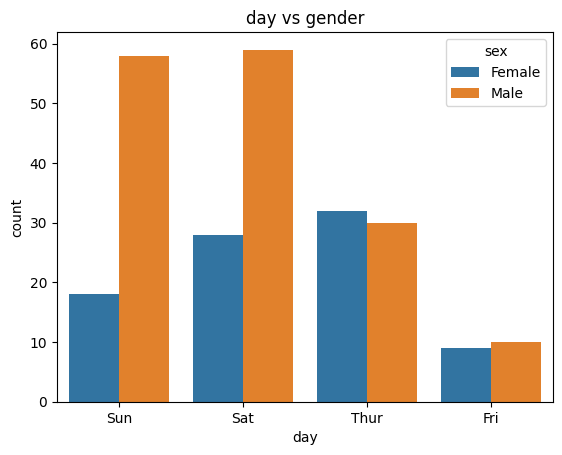

In [22]:
sns.countplot(x = df['day'], hue = 'sex', data=df)
plt.title("day vs gender")
plt.show()

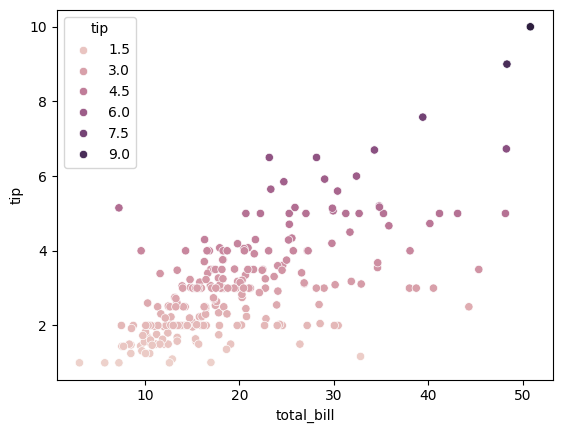

In [23]:
sns.scatterplot(x = df['total_bill'], y=df['tip'], hue='tip', data= df)

plt.show()

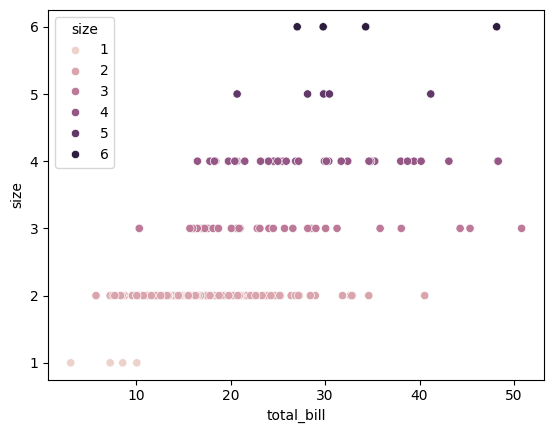

In [24]:
sns.scatterplot(x = df['total_bill'], y=df['size'], hue='size', data= df)

plt.show()

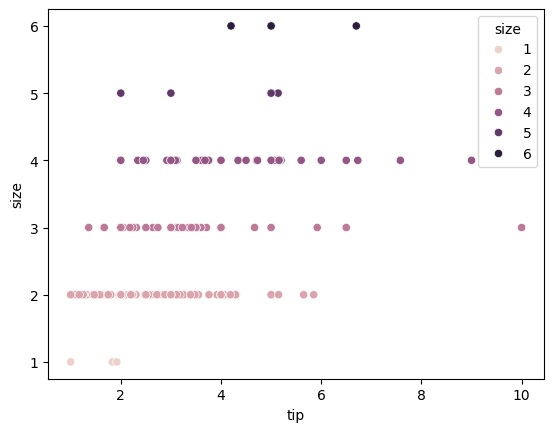

In [25]:
sns.scatterplot(x = df['tip'], y=df['size'], hue='size', data= df)

plt.show()

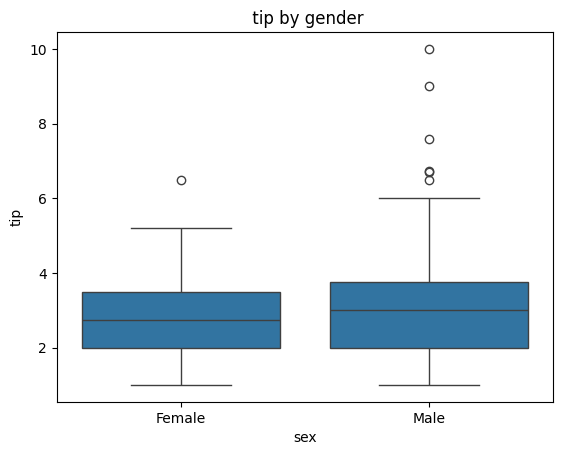

In [26]:
sns.boxplot(x = df['sex'], y = df['tip'], data=df)
plt.title(" tip by gender")
plt.show()

In [27]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

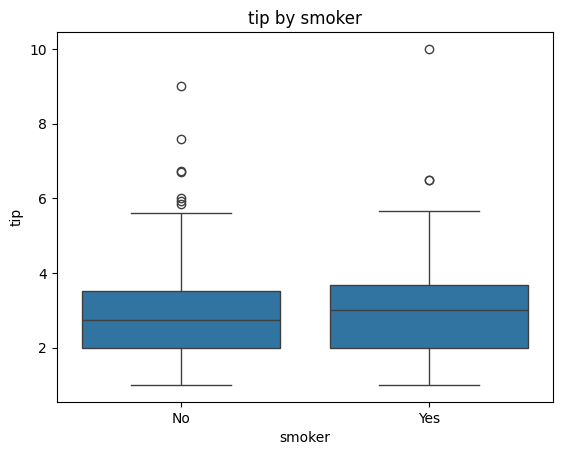

In [28]:
sns.boxplot(x = df['smoker'], y = df['tip'], data = df)
plt.title("tip by smoker")
plt.show()

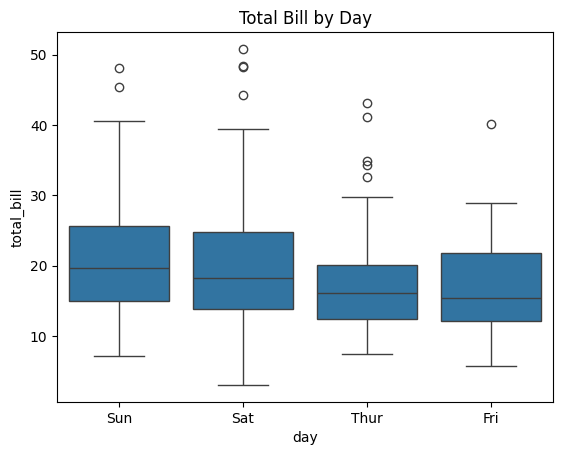

In [29]:
sns.boxplot(x='day', y='total_bill', data=df)
plt.title('Total Bill by Day')
plt.show()

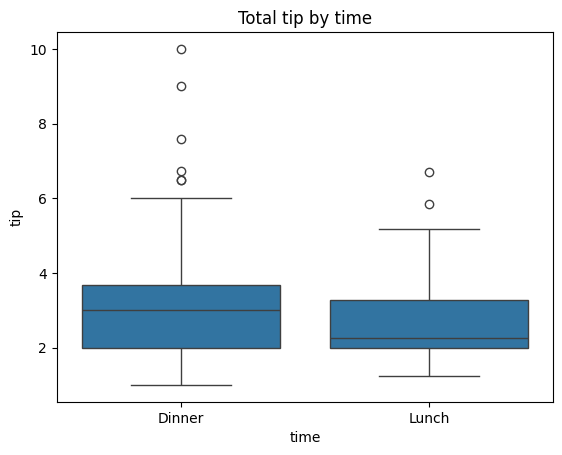

In [30]:
sns.boxplot(x='time', y='tip', data=df)
plt.title('Total tip by time')
plt.show()

# **MULTIVARIATE ANALYSIS**

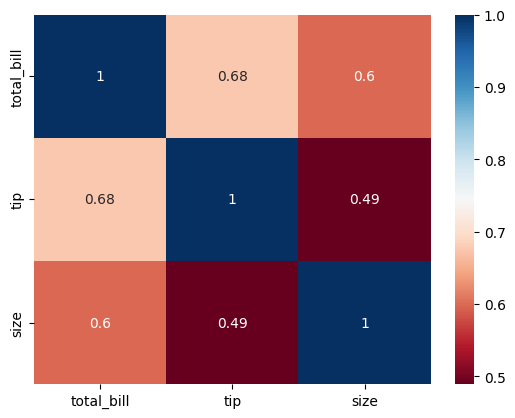

In [31]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cbar = True, cmap = 'RdBu')
plt.show()

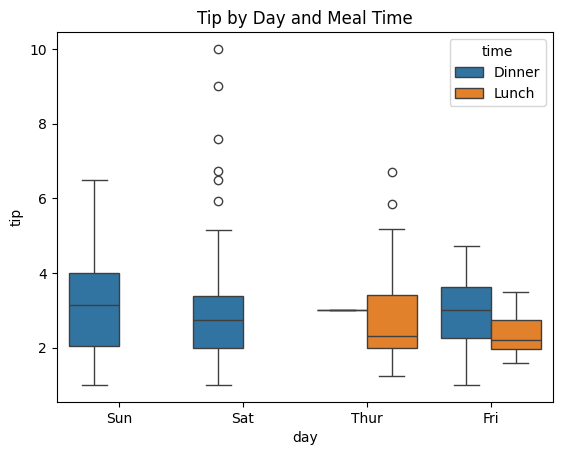

In [32]:
sns.boxplot(x='day',y='tip',hue='time',data=df)
plt.title('Tip by Day and Meal Time')
plt.show()

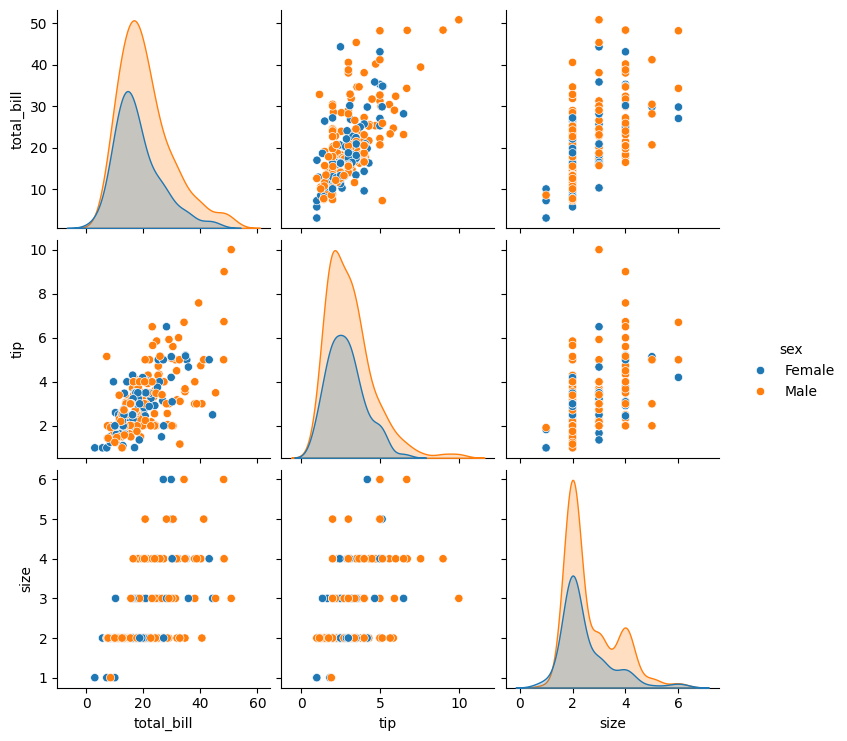

In [33]:
sns.pairplot(
    df,
    hue='sex',
    vars=['total_bill','tip','size']
)
plt.show()